In [ ]:
#Muhammad Zia Ul-haq 2311513013
#tugas 1
import threading

# --- BAGIAN 1: TANPA LOCK ---
saldo_tanpa_lock = 1000000

def transaksi_tanpa_lock():
    global saldo_tanpa_lock
    for _ in range(10000):
        # Operasi tarik 1 lalu setor 1
        saldo_tanpa_lock -= 1
        saldo_tanpa_lock += 1

threads_tanpa_lock = []

# Membuat dan menjalankan 10 thread
for _ in range(10):
    t = threading.Thread(target=transaksi_tanpa_lock)
    threads_tanpa_lock.append(t)
    t.start()

# Menunggu semua thread selesai
for t in threads_tanpa_lock:
    t.join()

print(f"Saldo akhir TANPA lock: {saldo_tanpa_lock}")


# --- BAGIAN 2: DENGAN LOCK ---
saldo_dengan_lock = 1000000
lock = threading.Lock()

def transaksi_dengan_lock():
    global saldo_dengan_lock
    for _ in range(10000):
        # Menggunakan lock untuk mencegah race condition
        with lock:
            saldo_dengan_lock -= 1
            saldo_dengan_lock += 1

threads_dengan_lock = []

# Membuat dan menjalankan 10 thread
for _ in range(10):
    t = threading.Thread(target=transaksi_dengan_lock)
    threads_dengan_lock.append(t)
    t.start()

# Menunggu semua thread selesai
for t in threads_dengan_lock:
    t.join()

print(f"Saldo akhir DENGAN lock: {saldo_dengan_lock}")

Saldo akhir TANPA lock: 1000000
Saldo akhir DENGAN lock: 1000000


1. Perbandingan dan Penjelasan Hasil:

Tanpa Lock: Saldo akhir sering kali tidak sama dengan 1.000.000. Hal ini terjadi karena Race Condition. Ketika beberapa thread mencoba membaca, mengubah, dan menulis nilai variabel saldo_tanpa_lock secara bersamaan, operasi tersebut dapat saling menimpa. Misalnya, Thread A membaca saldo (1.000.000), Thread B juga membaca saldo (1.000.000). Thread A mengurangi 1 dan menyimpan (999.999), lalu Thread B yang juga mengurangi 1 akan menyimpan (999.999) yang seharusnya menjadi 999.998.

Dengan Lock: Saldo akhir selalu konsisten di angka 1.000.000. Penambahan threading.Lock() (menggunakan sintaks with lock:) memastikan bahwa blok kode penarikan dan penyetoran (saldo -= 1; saldo += 1) bersifat atomic (hanya bisa dieksekusi oleh satu thread pada satu waktu). Thread lain yang ingin mengubah saldo harus menunggu hingga lock dilepaskan oleh thread yang sedang bekerja.


In [ ]:
#tugas 2
import threading
import queue
import time

# Fungsi untuk Producer
def producer(q, num_items, num_consumers):
    for i in range(1, num_items + 1):
        print(f"[Producer] Memproduksi item {i}")
        q.put(i)
        time.sleep(0.1) # Simulasi waktu produksi
        
    print("[Producer] Selesai memproduksi semua item.")
    
    # MENGIRIM SINYAL BERHENTI (POISON PILL)
    # Karena ada 3 consumer, kita harus mengirim 3 sinyal None 
    # agar masing-masing consumer menerima satu sinyal untuk berhenti.
    for _ in range(num_consumers):
        q.put(None)

# Fungsi untuk Consumer
def consumer(q, consumer_id):
    while True:
        item = q.get()
        
        # Mengecek sinyal berhenti
        if item is None:
            print(f"[Consumer-{consumer_id}] Menerima sinyal berhenti (None). Keluar...")
            q.task_done()
            break
            
        print(f"[Consumer-{consumer_id}] Memproses item {item}")
        time.sleep(0.3) # Simulasi waktu proses yang lebih lama dari produksi
        q.task_done()

# Setup Queue dan variabel
task_queue = queue.Queue()
jumlah_consumer = 3
jumlah_item = 10

# Membuat thread Producer (1 thread)
thread_producer = threading.Thread(target=producer, args=(task_queue, jumlah_item, jumlah_consumer))

# Membuat thread Consumer (3 thread)
threads_consumer = []
for i in range(1, jumlah_consumer + 1):
    t = threading.Thread(target=consumer, args=(task_queue, i))
    threads_consumer.append(t)

# Menjalankan semua thread
thread_producer.start()
for t in threads_consumer:
    t.start()

# Menunggu thread producer selesai
thread_producer.join()

# Menunggu antrean kosong dan semua consumer selesai
task_queue.join() 
for t in threads_consumer:
    t.join()

print("Semua proses Producer dan Consumer telah selesai dengan baik.")

[Producer] Memproduksi item 1
[Consumer-1] Memproses item 1
[Producer] Memproduksi item 2
[Consumer-2] Memproses item 2
[Producer] Memproduksi item 3
[Consumer-3] Memproses item 3
[Producer] Memproduksi item 4
[Consumer-1] Memproses item 4
[Producer] Memproduksi item 5
[Consumer-2] Memproses item 5
[Producer] Memproduksi item 6
[Consumer-3] Memproses item 6
[Producer] Memproduksi item 7
[Consumer-1] Memproses item 7
[Producer] Memproduksi item 8
[Consumer-2] Memproses item 8
[Producer] Memproduksi item 9
[Consumer-3] Memproses item 9
[Producer] Memproduksi item 10
[Consumer-1] Memproses item 10
[Producer] Selesai memproduksi semua item.
[Consumer-2] Menerima sinyal berhenti (None). Keluar...
[Consumer-3] Menerima sinyal berhenti (None). Keluar...
[Consumer-1] Menerima sinyal berhenti (None). Keluar...
Semua proses Producer dan Consumer telah selesai dengan baik.


2. Penjelasan Modifikasi Sinyal None:
Untuk memastikan ketiga consumer berhenti dengan baik (graceful shutdown) setelah producer selesai, kita harus menggunakan teknik yang disebut Sentinel Value atau Poison Pill.   Karena queue bekerja dengan prinsip FIFO (First-In, First-Out), satu sinyal None hanya akan diambil oleh satu consumer.Jika producer hanya mengirimkan satu None, maka hanya satu consumer yang akan berhenti, sedangkan dua consumer lainnya akan terjebak dalam infinite loop menunggu data (deadlock).Solusinya, setelah producer selesai memproduksi seluruh item, ia menggunakan perulangan for _ in range(num_consumers): untuk memasukkan tiga buah nilai None ke dalam queue.Hal ini menjamin masing-masing dari ketiga consumer akan menerima tepat satu sinyal None, sehingga mereka dapat mengeksekusi perintah break dan mengakhiri thread-nya secara aman.

In [6]:
!pip install matplotlib

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.3 MB ? eta -:--:--
   -- ------------------------------------- 0.5/9.3 MB 712.2 kB/s eta 0:00:13
   --- ------------------------------------ 0.8/9.3 MB 988.6 kB/s eta 0:00:09
   --- ------------------------------------ 0.8/9.3 MB 988.6 kB/s eta 0:00:09
   --- ------------------------------------ 0.8/9.3 MB 988.6 kB/s eta 0:00:09
   ---- ----------------------------------- 1.0/9.3 MB 658.5 kB/s eta 0:00:13
   ----- ---------------------------------- 1.3/9.3 MB 784.0 kB/s eta 0:00:11
   ----- ---------------------------------- 1.3/9.3 MB 784.0 kB/s eta 0:00:11
   ----- ----------------------


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: C:\Users\LENOVO\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Memulai eksperimen ThreadPoolExecutor...
Eksekusi dengan max_workers =  2 memakan waktu 2.5262 detik
Eksekusi dengan max_workers =  4 memakan waktu 1.3057 detik
Eksekusi dengan max_workers =  8 memakan waktu 0.7034 detik
Eksekusi dengan max_workers = 16 memakan waktu 0.4036 detik


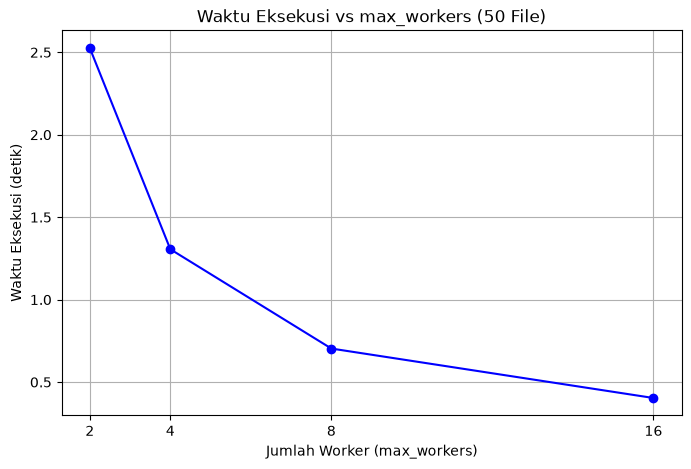

In [ ]:
#tugas 3
import concurrent.futures
import time
import matplotlib.pyplot as plt

# Simulasi fungsi pemrosesan file (I/O bound)
def proses_file(file_id):
    # Simulasi waktu yang dibutuhkan untuk membaca/menulis file
    time.sleep(0.1) 
    return f"File {file_id} diproses"

jumlah_file = 50
skenario_workers = [2, 4, 8, 16]
waktu_eksekusi = []

print("Memulai eksperimen ThreadPoolExecutor...")
for workers in skenario_workers:
    waktu_mulai = time.time()
    
    # Menjalankan executor dengan jumlah max_workers yang bervariasi
    with concurrent.futures.ThreadPoolExecutor(max_workers=workers) as executor:
        futures = [executor.submit(proses_file, i) for i in range(jumlah_file)]
        concurrent.futures.wait(futures)
        
    waktu_selesai = time.time()
    durasi = waktu_selesai - waktu_mulai
    waktu_eksekusi.append(durasi)
    print(f"Eksekusi dengan max_workers = {workers:2d} memakan waktu {durasi:.4f} detik")

# Plot Waktu Eksekusi vs max_workers
plt.figure(figsize=(8, 5))
plt.plot(skenario_workers, waktu_eksekusi, marker='o', linestyle='-', color='b')
plt.title('Waktu Eksekusi vs max_workers (50 File)')
plt.xlabel('Jumlah Worker (max_workers)')
plt.ylabel('Waktu Eksekusi (detik)')
plt.xticks(skenario_workers)
plt.grid(True)
plt.show()

3. Analisis Titik Jenuh pada ThreadPoolExecutor:

Menambah jumlah max_workers terus-menerus tidak selalu mempercepat proses. Dari plot yang dihasilkan, penurunan waktu eksekusi biasanya signifikan saat berpindah dari 2 ke 4 atau 8 worker, namun grafik akan mulai melandai (mencapai titik jenuh) saat mendekati 16 worker atau lebih. Titik jenuh ini terjadi karena beberapa faktor utama:   
JPG

Overhead Context Switching: Saat jumlah thread sangat banyak, Sistem Operasi harus bekerja lebih keras dan menghabiskan memori serta siklus CPU hanya untuk mengatur perpindahan (switch) tugas antar thread, dibandingkan benar-benar mengeksekusi isi tugas tersebut.

Keterbatasan Perangkat Keras (I/O Bottleneck): Tugas pemrosesan file sangat bergantung pada kecepatan baca/tulis hard drive atau SSD. Jika kecepatan maksimum disk sudah tercapai, sebanyak apa pun thread yang meminta data, waktu tunggunya akan tetap stagnan.

Python Global Interpreter Lock (GIL): Python memiliki GIL yang membatasi hanya satu thread yang dapat mengeksekusi bytecode Python pada satu waktu. Walaupun thread dapat berjalan bergantian saat melakukan operasi I/O (seperti time.sleep atau baca disk), eksekusi proses yang memakan CPU secara paralel sejati tetap terhambat.

4. Refleksi Singkat (Kasus Threading vs Multiprocessing)

Threading Python sangat membantu pada tugas I/O-bound yang banyak menunggu sumber daya eksternal. Contoh nyatanya adalah aplikasi web scraper yang mengunduh ribuan data dari berbagai API/URL. Saat satu thread menunggu respons server (jaringan lambat), thread lain dapat langsung mengirim permintaan baru sehingga total waktu unduh menjadi jauh lebih cepat.

Sebaliknya, threading Python tidak akan membantu pada tugas CPU-bound karena batasan Global Interpreter Lock (GIL). Contoh nyatanya adalah pemrosesan video atau perhitungan matriks besar untuk machine learning. Karena GIL hanya mengizinkan satu thread mengeksekusi instruksi Python pada satu waktu, threading justru bisa memperlambat proses akibat overhead context-switching. Kasus perhitungan berat seperti ini harus diselesaikan dengan multiprocessing agar tugas bisa didistribusikan secara paralel ke beberapa inti (core) prosesor yang berbeda.